In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
import leidenalg
import squidpy as sq
from scipy import sparse
from matplotlib.colors import ListedColormap
import os
import geopandas as gpd
import decoupler as dc
from scipy.io import mmread
from sklearn.utils import sparsefuncs
import scipy.sparse as sp

In [3]:
sample = "Pat2_W12"

um = '008'
print ("Reading in segmentation for sample " + sample)
data_directory = "../segmentation/" + sample + "/"
adata = anndata.read_h5ad(data_directory + sample + "_" + um + ".h5ad")
adata

Reading in segmentation for sample Pat2_W12


AnnData object with n_obs × n_vars = 99157 × 18085
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'

In [4]:
sc.pp.filter_cells(adata, min_genes=5)
sc.pp.filter_genes(adata, min_cells=5)

#remove cells with high mitochondrial content
mito_genes = adata.var_names.str.startswith('MT-')
adata.obs['percent_mito'] = np.sum(adata[:, mito_genes].X, axis=1) / np.sum(adata.X, axis=1)
adata = adata[adata.obs['percent_mito'] < 0.05, :]

#remove mitochondrial genes
adata = adata[:, [gene for gene in adata.var_names if not gene.startswith('MT-')]]
adata

View of AnnData object with n_obs × n_vars = 77050 × 15678
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'percent_mito'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    obsm: 'spatial'

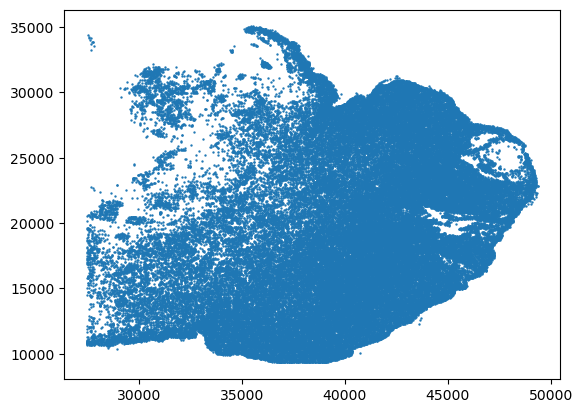

In [5]:
plt.scatter(adata.obsm["spatial"][:,0], adata.obsm["spatial"][:,1], s=0.5)

In [6]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.scale(adata)

/home/fceccarelli/miniconda3/envs/visium/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [7]:
# PCA
sc.tl.pca(adata)
# Compute nearest neighbors
sc.pp.neighbors(adata)
# UMAP for visualization
sc.tl.umap(adata)

2025-03-21 10:45:54.278532: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-21 10:45:54.298759: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-21 10:45:54.321983: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-21 10:45:54.328845: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-21 10:45:54.345268: I tensorflow/core/platform/cpu_feature_guar

/tmp/ipykernel_225024/1794627083.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.3)


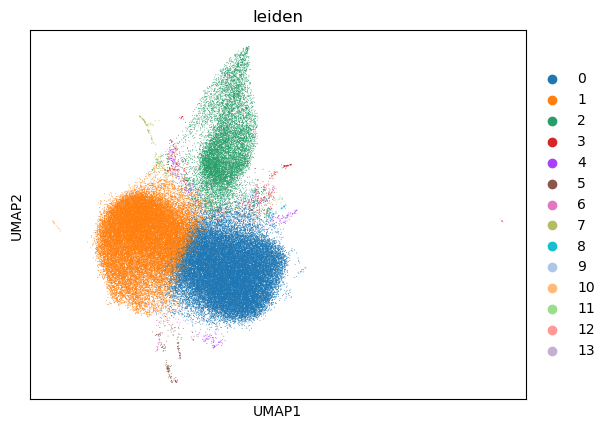

In [8]:
# Clustering
sc.tl.leiden(adata, resolution=0.3)  
# Visualize clusters
sc.pl.umap(adata, color=["leiden"])

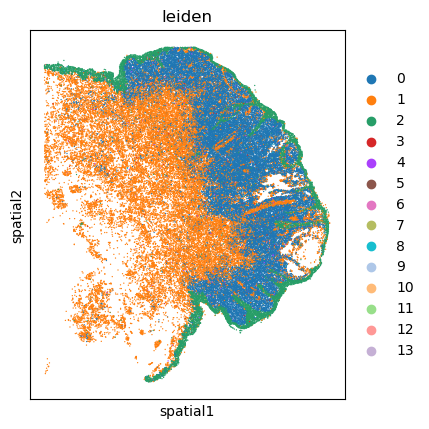

In [9]:
sc.pl.spatial(adata, color='leiden', spot_size=100, alpha_img=1)

In [10]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")

/home/fceccarelli/miniconda3/envs/visium/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/fceccarelli/miniconda3/envs/visium/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/fceccarelli/miniconda3/envs/visium/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/fceccarelli/miniconda3/envs/visium/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/fceccarelli/miniconda3/envs/visium/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value enco

In [11]:
adata.obs["leiden"].value_counts()

0     34401
1     31037
2     10070
3       421
4       303
5       214
6       174
7       173
8        72
9        66
10       50
11       31
12       24
13       14
Name: leiden, dtype: int64

In [12]:
clusters = adata.obs['leiden'].unique()
de_results = {}
for cluster in clusters:
    cluster_results = pd.DataFrame({
        'gene': adata.uns['rank_genes_groups']['names'][cluster],
        'logfoldchanges': adata.uns['rank_genes_groups']['logfoldchanges'][cluster],
        'pvals': adata.uns['rank_genes_groups']['pvals'][cluster],
        'pvals_adj': adata.uns['rank_genes_groups']['pvals_adj'][cluster]
    })
    #only include positive logfoldchanges
    #cluster_results = cluster_results[cluster_results['logfoldchanges'] > 0]
    de_results[cluster] = cluster_results

#print the top 20 genes for each cluster sorted by p-value
for cluster, results in de_results.items():
    print(f"Cluster {cluster}")
    print(results.head(50))
    print("\n")

Cluster 2
       gene  logfoldchanges          pvals      pvals_adj
0    S100A9             NaN   0.000000e+00   0.000000e+00
1    S100A8             NaN   0.000000e+00   0.000000e+00
2    KRTDAP             NaN   0.000000e+00   0.000000e+00
3      KRT5             NaN  5.541701e-282  2.172070e-278
4       FLG             NaN  2.141794e-232  6.715811e-229
5       LOR             NaN  1.108621e-192  2.896827e-189
6      DMKN             NaN  1.111526e-167  2.489501e-164
7     KRT10             NaN  1.033372e-162  2.025152e-159
8      SBSN             NaN  9.047440e-149  1.576064e-145
9       DSP             NaN  2.595067e-143  4.068546e-140
10   CALML5             NaN  3.410216e-123  4.860488e-120
11     KRT1             NaN  6.578507e-115  8.594819e-112
12     PERP             NaN   1.097484e-97   1.323566e-94
13      SFN             NaN   2.599614e-77   2.911197e-74
14   TRIM29             NaN   8.468261e-72   8.851026e-69
15   SPRR1B             NaN   6.138298e-46   6.014765e-43
16  

In [13]:
# Pat03_W4
cell_type_names = {
    "0": "Melanocytes", 
    "1": "Macrophages",
    "2": "Keratinocytes",
    "3": "Keratinocytes",
    "4": "Keratinocytes",
    "5": "Keratinocytes",
    "6": "Keratinocytes",
    "7": "Keratinocytes",
    "8": "Keratinocytes",
    "9": "Keratinocytes",
    "10": "Keratinocytes",
    "11": "Keratinocytes",
    "12": "Keratinocytes",
    "13": "Keratinocytes"
}

adata.obs["cell_type"] = adata.obs["leiden"].astype(str).map(cell_type_names)

In [ ]:
sc.pl.spatial(adata, color='cell_type', spot_size=70, alpha_img=1)

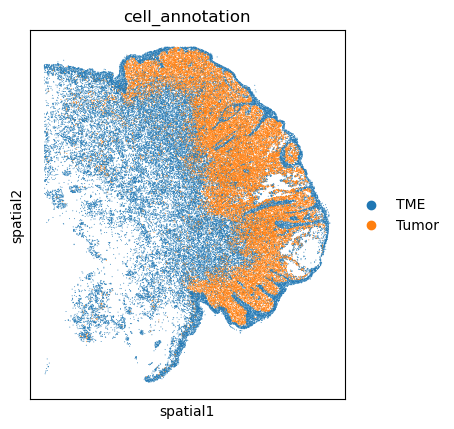

In [15]:
sc.pl.spatial(adata, color='cell_annotation', spot_size=70, alpha_img=1)

In [14]:
adata.obs["cell_annotation"] = np.where(
    adata.obs["cell_type"] == "Melanocytes", "Tumor", "TME")

In [16]:
adata.write(data_directory + sample + "_" + um + "_processed.h5ad")